In [11]:
import numpy as np
import scipy
from scipy.integrate import solve_ivp
import pandas as pd
from matplotlib import pyplot as plt

In [12]:
n=1

In [53]:
def deterministic_part(t,y,lambda_C,mutation_coefficient,killing_N,killing_T,C_M,
                       activation_T,death_T,
                       activation_N,death_N):
    
    dy = np.zeros(2*n+1)
    total_cancer = np.sum(y[:n])
    total_T = np.sum(y[n:-1])
    N = y[-1]
    for i in range(n):
        dy[i] = lambda_C*y[i]*(1-total_cancer/C_M)-killing_N*N
        dy[i+n] = -death_T*y[n+i]+activation_T*y[i]/(C_M+total_cancer)
        for j in range(n):
            if i!=j:
                dy[i] += lambda_C*mutation_coefficient/abs(j-i)*y[j]-lambda_C*mutation_coefficient/abs(j-i)*y[i]*(1-total_cancer/C_M)-killing_T*y[i]*y[n+j]/abs(abs(j-i)+1)
            if i == j:
                dy[i] += -killing_T*y[i]*y[n+j]
    dy[2*n] = activation_N*total_cancer/(total_cancer+C_M)-death_N*y[2*n]
    return list(dy)
    
params = [1.0,0.0,0.1,0.1,0.1,0.1,0.1,0.2,0.1]
lambda_C,mutation_coefficient,killing_N,killing_T,C_M,activation_T,death_T,activation_N,death_N = params

def deterministic_part_parametrised(t,y):
    return deterministic_part(t,y,lambda_C,mutation_coefficient,killing_N,killing_T,C_M,activation_T,death_T,activation_N,death_N)


In [54]:
y0 = [0.7,0.1,0.1]
tspan = (0.0,50.0)
print(len(C0))

3


In [55]:
sol = solve_ivp(deterministic_part_parametrised,tspan,y0)

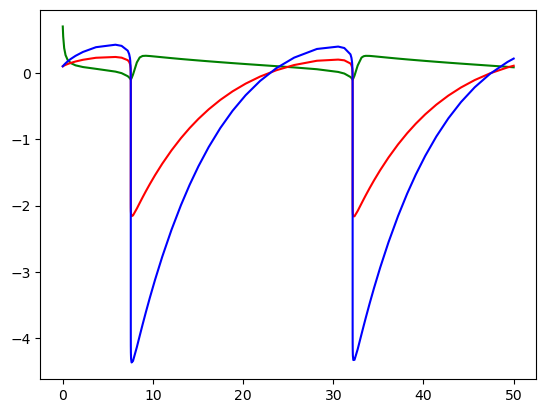

In [56]:
time = sol.t
C = sol.y[0]
T = sol.y[1]
N = sol.y[2]

fig,ax = plt.subplots()
ax.plot(time,C,'g')
ax.plot(time,T,'r')
ax.plot(time,N,'b')
plt.show()